# Benchmark Comparison

In this notebook, we compare different portfolio strategies against simple benchmark portfolios.

The objective is to evaluate whether more advanced allocations, such as Balanced and Risk Parity portfolios, provide better risk-adjusted performance compared to basic benchmarks.

We compare:

- SPY Only
- 60/40 Portfolio
- Equal Weight Portfolio
- Balanced Portfolio
- Risk Parity Portfolio

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Project folders
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
IMAGES_DIR = PROJECT_ROOT / "images"

OUTPUTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

# Load daily returns
returns = pd.read_csv(
    DATA_DIR / "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

returns.head()

,GLD,QQQ,SPY,TLT
Date,,,,
2018-01-03,-0.002637,0.009717,0.006325,0.004782
2018-01-04,0.005127,0.001749,0.004215,-0.000159
2018-01-05,-0.001036,0.010043,0.006664,-0.002856
2018-01-08,-0.000160,0.003891,0.001829,-0.000637
2018-01-09,-0.004628,0.000062,0.002264,-0.013372


In [2]:
assets = returns.columns
n_assets = len(assets)

initial_portfolio_value = 10_000
trading_days = 252
risk_free_rate = 0.00

mean_daily_returns = returns.mean()
cov_daily_matrix = returns.cov()
cov_annual_matrix = cov_daily_matrix * trading_days

print("Assets:")
print(list(assets))
print(f"Number of assets: {n_assets}")

Assets:
['GLD', 'QQQ', 'SPY', 'TLT']
Number of assets: 4


In [3]:
def portfolio_volatility(weights, cov_matrix):
    """
    Calculates portfolio volatility.
    """
    return np.sqrt(weights.T @ cov_matrix @ weights)


def risk_contributions(weights, cov_matrix):
    """
    Calculates each asset's percentage contribution to total portfolio risk.
    """
    portfolio_vol = portfolio_volatility(weights, cov_matrix)

    marginal_contribution = cov_matrix @ weights
    absolute_risk_contribution = weights * marginal_contribution / portfolio_vol
    percentage_risk_contribution = absolute_risk_contribution / portfolio_vol

    return percentage_risk_contribution


def risk_parity_objective(weights, cov_matrix):
    """
    Objective function for Risk Parity optimization.
    """
    target_risk_contribution = np.ones(len(weights)) / len(weights)
    actual_risk_contribution = risk_contributions(weights, cov_matrix)

    return np.sum((actual_risk_contribution - target_risk_contribution) ** 2)

In [4]:
initial_guess = np.ones(n_assets) / n_assets

constraints = (
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    },
)

bounds = tuple((0, 1) for _ in range(n_assets))

risk_parity_solution = minimize(
    fun=risk_parity_objective,
    x0=initial_guess,
    args=(cov_annual_matrix,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

risk_parity_weights = pd.Series(
    risk_parity_solution.x,
    index=assets,
    name="Risk Parity"
)

risk_parity_weights

GLD    0.269773
QQQ    0.163727
SPY    0.212473
TLT    0.354027
Name: Risk Parity, dtype: float64

In [5]:
benchmark_portfolios = {
    "SPY Only": {
        "SPY": 1.00,
        "QQQ": 0.00,
        "TLT": 0.00,
        "GLD": 0.00
    },
    "60/40 Portfolio": {
        "SPY": 0.60,
        "QQQ": 0.00,
        "TLT": 0.40,
        "GLD": 0.00
    },
    "Equal Weight": {
        "SPY": 0.25,
        "QQQ": 0.25,
        "TLT": 0.25,
        "GLD": 0.25
    },
    "Balanced": {
        "SPY": 0.40,
        "QQQ": 0.30,
        "TLT": 0.20,
        "GLD": 0.10
    },
    "Risk Parity": risk_parity_weights.to_dict()
}

# Convert to DataFrame and reorder columns to match returns
benchmark_weights = pd.DataFrame(benchmark_portfolios).T
benchmark_weights = benchmark_weights[assets]

benchmark_weights.to_csv(
    OUTPUTS_DIR / "benchmark_portfolio_weights.csv"
)

benchmark_weights

,GLD,QQQ,SPY,TLT
SPY Only,0.000000,0.000000,1.000000,0.000000
60/40 Portfolio,0.000000,0.000000,0.600000,0.400000
Equal Weight,0.250000,0.250000,0.250000,0.250000
Balanced,0.100000,0.300000,0.400000,0.200000
Risk Parity,0.269773,0.163727,0.212473,0.354027


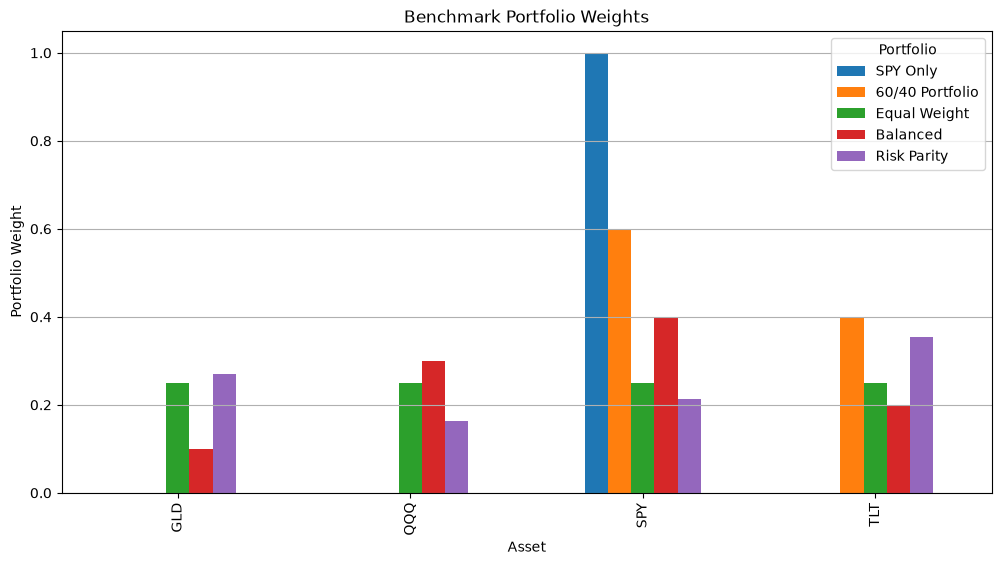

In [6]:
ax = benchmark_weights.T.plot(kind="bar", figsize=(12, 6))

plt.title("Benchmark Portfolio Weights")
plt.xlabel("Asset")
plt.ylabel("Portfolio Weight")
plt.grid(axis="y")
plt.legend(title="Portfolio")

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "benchmark_portfolio_weights.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
def calculate_portfolio_metrics(portfolio_returns, benchmark_returns=None):
    """
    Calculates performance, risk, downside risk, beta, and correlation metrics.
    """
    portfolio_values = initial_portfolio_value * (1 + portfolio_returns).cumprod()

    final_value = portfolio_values.iloc[-1]
    total_return = final_value / portfolio_values.iloc[0] - 1

    annualized_return = portfolio_returns.mean() * trading_days
    annualized_volatility = portfolio_returns.std() * np.sqrt(trading_days)

    sharpe_ratio = (
        (annualized_return - risk_free_rate) / annualized_volatility
        if annualized_volatility != 0
        else np.nan
    )

    running_max = portfolio_values.cummax()
    drawdown = portfolio_values / running_max - 1
    max_drawdown = drawdown.min()

    var_95 = np.percentile(portfolio_returns, 5)
    expected_shortfall_95 = portfolio_returns[
        portfolio_returns <= var_95
    ].mean()

    if benchmark_returns is not None:
        covariance_with_benchmark = np.cov(
            portfolio_returns,
            benchmark_returns
        )[0, 1]

        benchmark_variance = np.var(benchmark_returns)

        beta = (
            covariance_with_benchmark / benchmark_variance
            if benchmark_variance != 0
            else np.nan
        )

        correlation = portfolio_returns.corr(benchmark_returns)
    else:
        beta = np.nan
        correlation = np.nan

    return {
        "Final Value": final_value,
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown,
        "Historical VaR 95%": var_95,
        "Historical Expected Shortfall 95%": expected_shortfall_95,
        "Beta vs SPY": beta,
        "Correlation vs SPY": correlation
    }

In [8]:
spy_returns = returns["SPY"]

benchmark_daily_returns = pd.DataFrame(index=returns.index)
benchmark_values = pd.DataFrame(index=returns.index)

benchmark_metrics = {}

for portfolio_name in benchmark_weights.index:
    weights = benchmark_weights.loc[portfolio_name]

    portfolio_returns = returns @ weights.values

    benchmark_daily_returns[portfolio_name] = portfolio_returns
    benchmark_values[portfolio_name] = initial_portfolio_value * (
        1 + portfolio_returns
    ).cumprod()

    benchmark_metrics[portfolio_name] = calculate_portfolio_metrics(
        portfolio_returns=portfolio_returns,
        benchmark_returns=spy_returns
    )

benchmark_comparison_summary = pd.DataFrame(benchmark_metrics).T

benchmark_comparison_summary.to_csv(
    OUTPUTS_DIR / "benchmark_comparison_summary.csv"
)

benchmark_values.to_csv(
    OUTPUTS_DIR / "benchmark_portfolio_values.csv"
)

benchmark_comparison_summary

,Final Value,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Historical VaR 95%,Historical Expected Shortfall 95%,Beta vs SPY,Correlation vs SPY
SPY Only,31688.764401,2.148959,0.154481,0.191786,0.805489,-0.337173,-0.017715,-0.029154,1.000468,1.000000
60/40 Portfolio,20143.807946,1.002949,0.090147,0.122866,0.733708,-0.272353,-0.012035,-0.018106,0.555695,0.867001
Equal Weight,27286.195039,1.716269,0.126101,0.124146,1.015749,-0.251545,-0.011915,-0.018212,0.539388,0.832878
Balanced,29434.977963,1.925542,0.138521,0.149518,0.926453,-0.273791,-0.014827,-0.022092,0.738260,0.946520
Risk Parity,22974.128845,1.288451,0.104221,0.110616,0.942185,-0.253305,-0.011015,-0.015952,0.391517,0.678491


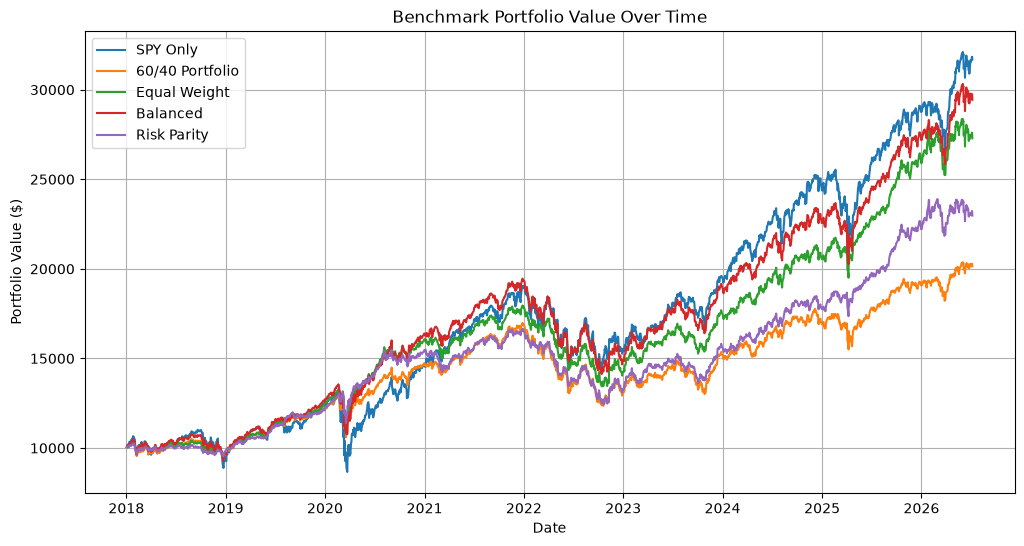

In [9]:
plt.figure(figsize=(12, 6))

for portfolio_name in benchmark_values.columns:
    plt.plot(
        benchmark_values.index,
        benchmark_values[portfolio_name],
        label=portfolio_name
    )

plt.title("Benchmark Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "benchmark_portfolio_values_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

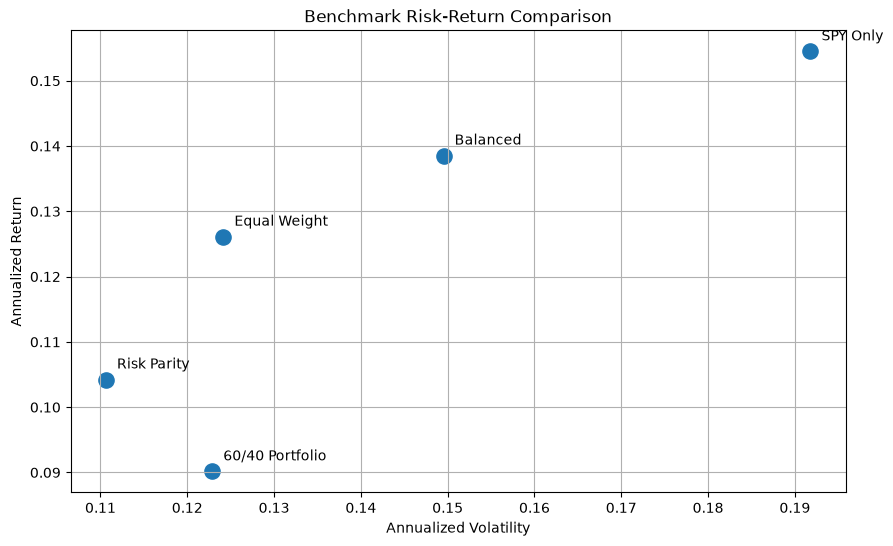

In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(
    benchmark_comparison_summary["Annualized Volatility"],
    benchmark_comparison_summary["Annualized Return"],
    s=120
)

for portfolio_name in benchmark_comparison_summary.index:
    plt.annotate(
        portfolio_name,
        (
            benchmark_comparison_summary.loc[portfolio_name, "Annualized Volatility"],
            benchmark_comparison_summary.loc[portfolio_name, "Annualized Return"]
        ),
        textcoords="offset points",
        xytext=(8, 8)
    )

plt.title("Benchmark Risk-Return Comparison")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.grid(True)

plt.savefig(
    IMAGES_DIR / "benchmark_risk_return_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

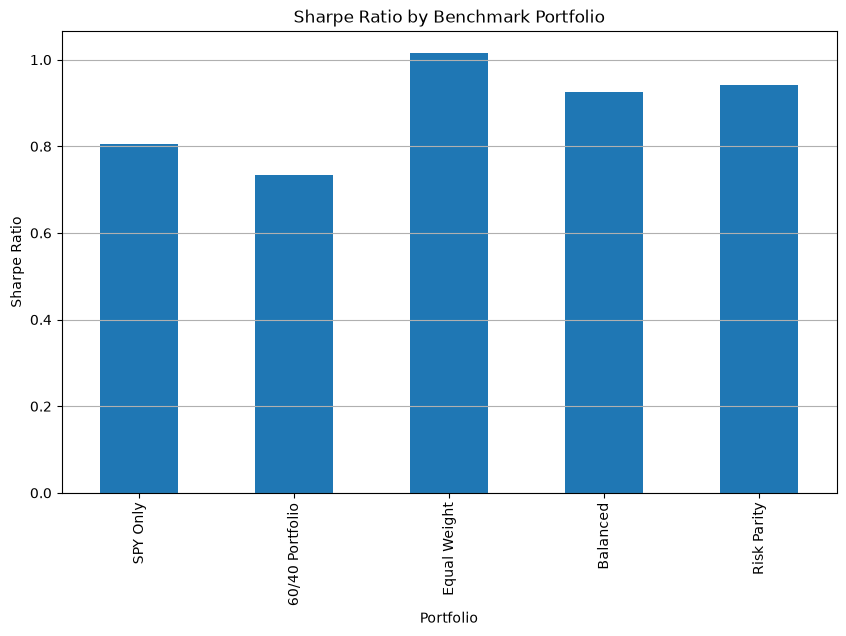

In [11]:
ax = benchmark_comparison_summary["Sharpe Ratio"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sharpe Ratio by Benchmark Portfolio")
plt.xlabel("Portfolio")
plt.ylabel("Sharpe Ratio")
plt.grid(axis="y")

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "benchmark_sharpe_ratio_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

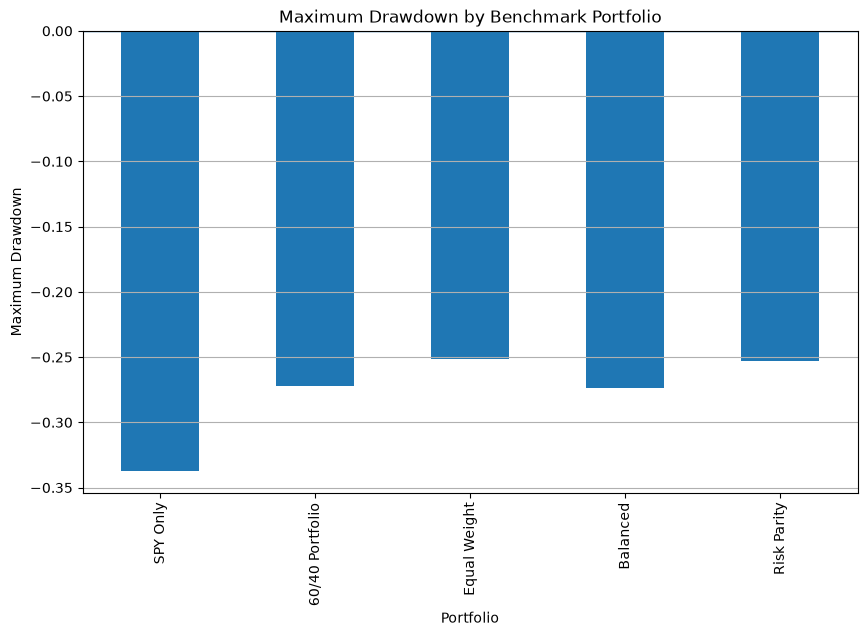

In [12]:
ax = benchmark_comparison_summary["Maximum Drawdown"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Maximum Drawdown by Benchmark Portfolio")
plt.xlabel("Portfolio")
plt.ylabel("Maximum Drawdown")
plt.axhline(0, linewidth=1)
plt.grid(axis="y")

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "benchmark_max_drawdown_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

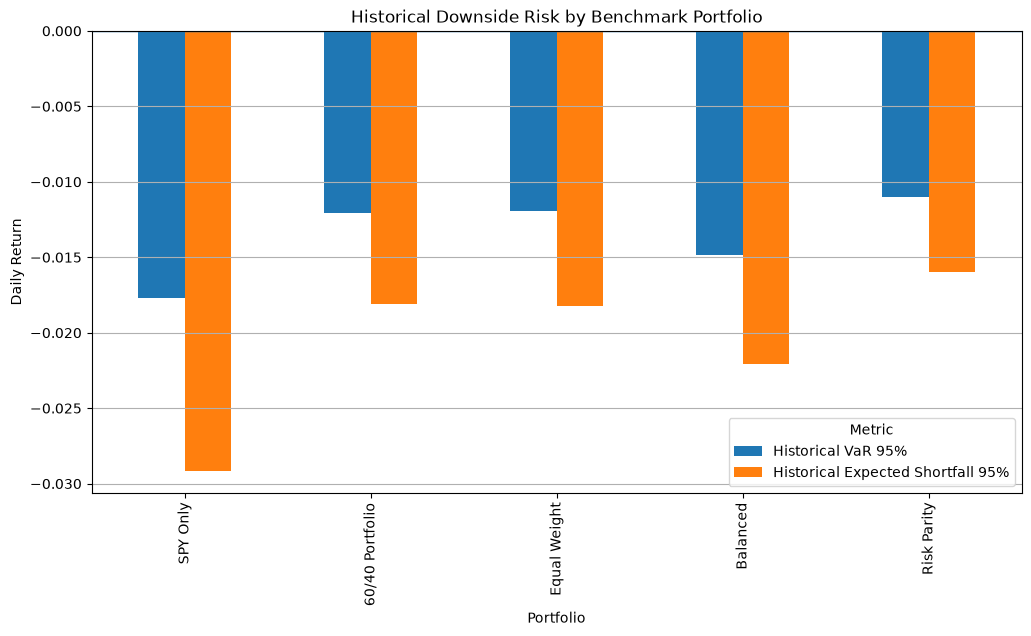

In [13]:
downside_risk = benchmark_comparison_summary[
    ["Historical VaR 95%", "Historical Expected Shortfall 95%"]
]

ax = downside_risk.plot(kind="bar", figsize=(12, 6))

plt.title("Historical Downside Risk by Benchmark Portfolio")
plt.xlabel("Portfolio")
plt.ylabel("Daily Return")
plt.axhline(0, linewidth=1)
plt.grid(axis="y")
plt.legend(title="Metric")

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "benchmark_downside_risk_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

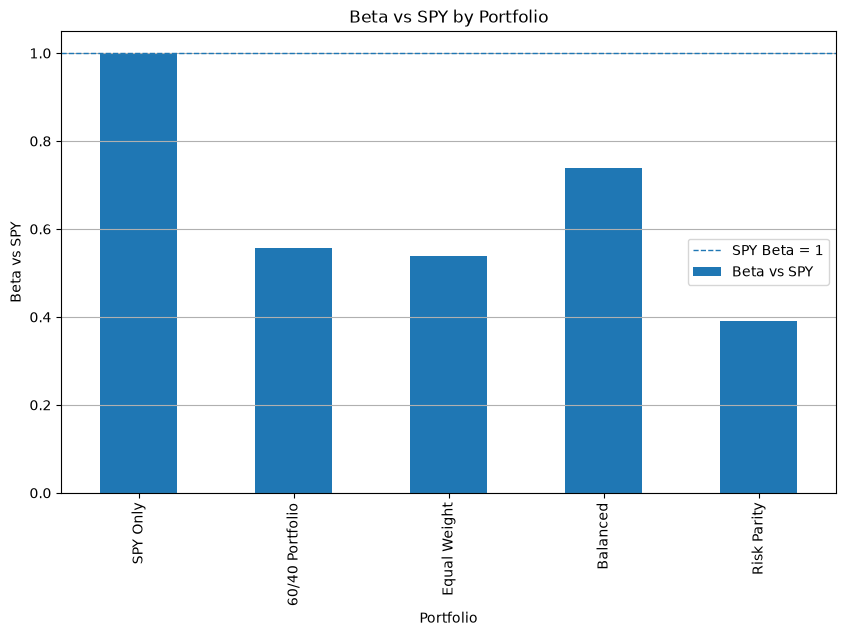

In [14]:
ax = benchmark_comparison_summary["Beta vs SPY"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Beta vs SPY by Portfolio")
plt.xlabel("Portfolio")
plt.ylabel("Beta vs SPY")
plt.axhline(1, linestyle="--", linewidth=1, label="SPY Beta = 1")
plt.grid(axis="y")
plt.legend()

fig = ax.get_figure()
fig.savefig(
    IMAGES_DIR / "benchmark_beta_vs_spy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Benchmark Comparison Interpretation

This benchmark comparison evaluates how different portfolio construction approaches perform relative to simple reference portfolios.

The analysis compares five portfolios:

- **SPY Only**, representing full exposure to the U.S. equity market
- **60/40 Portfolio**, representing a traditional equity-bond allocation
- **Equal Weight Portfolio**, allocating the same capital weight to each asset
- **Balanced Portfolio**, combining equity, bonds, and gold with a growth-oriented allocation
- **Risk Parity Portfolio**, allocating weights based on risk contribution rather than capital allocation

### Performance and Return

The **SPY Only** portfolio is the simplest benchmark and provides direct exposure to the equity market. It can generate strong returns during periods of market growth, but it also carries higher exposure to equity market downturns.

The **Balanced Portfolio** includes both SPY and QQQ, which increases its exposure to equities and growth-oriented assets. This may improve return potential, but it can also increase volatility and downside risk.

The **60/40 Portfolio** and **Equal Weight Portfolio** provide more diversification by combining equities with defensive assets such as Treasury bonds and gold. These portfolios may generate lower returns during strong equity markets, but they can offer better downside protection.

The **Risk Parity Portfolio** focuses on balancing risk contributions across assets. This means that more volatile assets may receive lower capital weights, while lower-volatility or diversifying assets may receive higher weights.

### Risk and Volatility

Annualized volatility helps measure how much each portfolio fluctuates over time.

Portfolios with higher equity exposure, such as **SPY Only** and **Balanced**, generally tend to show higher volatility because they are more sensitive to stock market movements.

More diversified portfolios, such as **60/40**, **Equal Weight**, and **Risk Parity**, may reduce volatility by combining assets that do not always move in the same direction.

### Sharpe Ratio

The Sharpe Ratio measures risk-adjusted return. A higher Sharpe Ratio means that the portfolio generated more return per unit of risk.

This is important because the best portfolio is not necessarily the one with the highest return. A portfolio with slightly lower returns but much lower volatility may be more attractive from a risk-adjusted perspective.

The comparison helps identify whether more diversified or optimized allocations improve efficiency relative to simple benchmarks.

### Maximum Drawdown

Maximum drawdown measures the largest historical decline from a previous peak.

This is especially important from an investor perspective because large drawdowns can be difficult to tolerate, even if long-term returns are attractive.

A portfolio with lower maximum drawdown may be more suitable for investors who prioritize capital preservation and downside protection.

### Historical VaR and Expected Shortfall

Historical Value at Risk and Expected Shortfall provide additional downside risk measures.

- **Historical VaR 95%** estimates the loss threshold for the worst 5% of historical daily returns.
- **Historical Expected Shortfall 95%** measures the average loss within those worst 5% outcomes.

Expected Shortfall is especially useful because it gives more information about tail risk than VaR alone.

### Beta and Correlation vs SPY

Beta vs SPY measures how sensitive each portfolio is to movements in the U.S. equity market.

A beta close to 1 means the portfolio behaves similarly to SPY.  
A beta below 1 means the portfolio is less sensitive to equity market movements.  
A beta above 1 means the portfolio has higher market sensitivity.

Correlation vs SPY shows how closely each portfolio moves with SPY. Lower correlation may indicate better diversification benefits.

### Overall Conclusion

This benchmark analysis shows that portfolio evaluation should not be based only on final value or total return.

Different portfolios serve different purposes:

- **SPY Only** may offer strong return potential, but with higher equity market risk.
- **60/40 Portfolio** provides a traditional diversified benchmark with reduced equity exposure.
- **Equal Weight Portfolio** offers simple diversification across all selected assets.
- **Balanced Portfolio** provides a more growth-oriented multi-asset allocation.
- **Risk Parity Portfolio** focuses on improving diversification from a risk contribution perspective.

Overall, the results help compare return potential, volatility, downside risk, drawdowns, beta exposure, and risk-adjusted performance.